# Heart Disease Prediction Using Machine Learning

---

##  Abstract

Heart disease is one of the leading causes of death worldwide. Early prediction and diagnosis can significantly reduce mortality rates and improve patient outcomes. Traditional diagnosis methods rely heavily on clinical tests and physician experience.  

This project aims to develop a Machine Learning model that predicts the presence of heart disease using patient medical attributes. Multiple classification algorithms were implemented and evaluated. The dataset was preprocessed, balanced using SMOTE, and optimized using hyperparameter tuning to improve model performance.

---

## Problem Statement

To design and implement a Machine Learning-based predictive system that can accurately classify whether a patient has heart disease based on medical parameters.

---

##  Objectives

- To analyze patient medical data
- To perform data preprocessing and cleaning
- To handle class imbalance using SMOTE
- To train multiple Machine Learning models
- To tune hyperparameters for improved performance
- To evaluate models using standard metrics
- To identify the best-performing model

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Dataset Description

The dataset contains patient medical records with the following attributes:

- **Age** – Age of the patient  
- **Sex** – Gender of the patient  
- **Chest Pain Type** – Type of chest pain experienced  
- **Resting Blood Pressure** – Blood pressure at rest  
- **Cholesterol** – Serum cholesterol level  
- **Fasting Blood Sugar** – Blood sugar level  
- **Resting ECG** – Electrocardiographic results  
- **Maximum Heart Rate** – Maximum heart rate achieved  
- **Exercise Induced Angina** – Chest pain during exercise  
- **Target** – Presence of heart disease (1 = Yes, 0 = No)

In [2]:
data_1 = pd.read_csv('values (1).csv')


In [3]:
data_1


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [8]:
data_1.shape

(180, 14)

In [5]:
data_2 = pd.read_csv('labels (1).csv')

In [6]:
data_2

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [7]:
data_2=data_2.iloc[:,-1]

In [8]:
data_2

0      0
1      0
2      1
3      1
4      0
      ..
175    1
176    1
177    1
178    0
179    0
Name: heart_disease_present, Length: 180, dtype: int64

In [15]:
combined_data=pd.concat([data_1,data_2],axis=1)

In [16]:
combined_data

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [17]:
data_2.shape

(180,)

In [18]:
combined_data.shape

(180, 15)

In [19]:
combined_data.drop('patient_id',axis=1,inplace=True)

In [20]:
combined_data

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


##  Data Preprocessing

### 1. Handling Missing Values
The dataset was checked for null values and ensured that no missing data affected model training.

### 2. Removing Duplicates
Duplicate records were removed to prevent bias.

### 3. Encoding Categorical Variables
Categorical features were converted into numerical format for model compatibility.

### 4. Feature Scaling
StandardScaler was applied to normalize numerical features and improve model convergence.

In [21]:
combined_data.shape

(180, 14)

In [22]:
combined_data.isnull().sum()

slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [23]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

## EXPLORATORY DATA ANALYSIS(EDA)

In [24]:
combined_data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [25]:
combined_data.describe(include='object')

,thal
count,180
unique,3
top,normal
freq,98


In [26]:
# histplot to understand the distribution

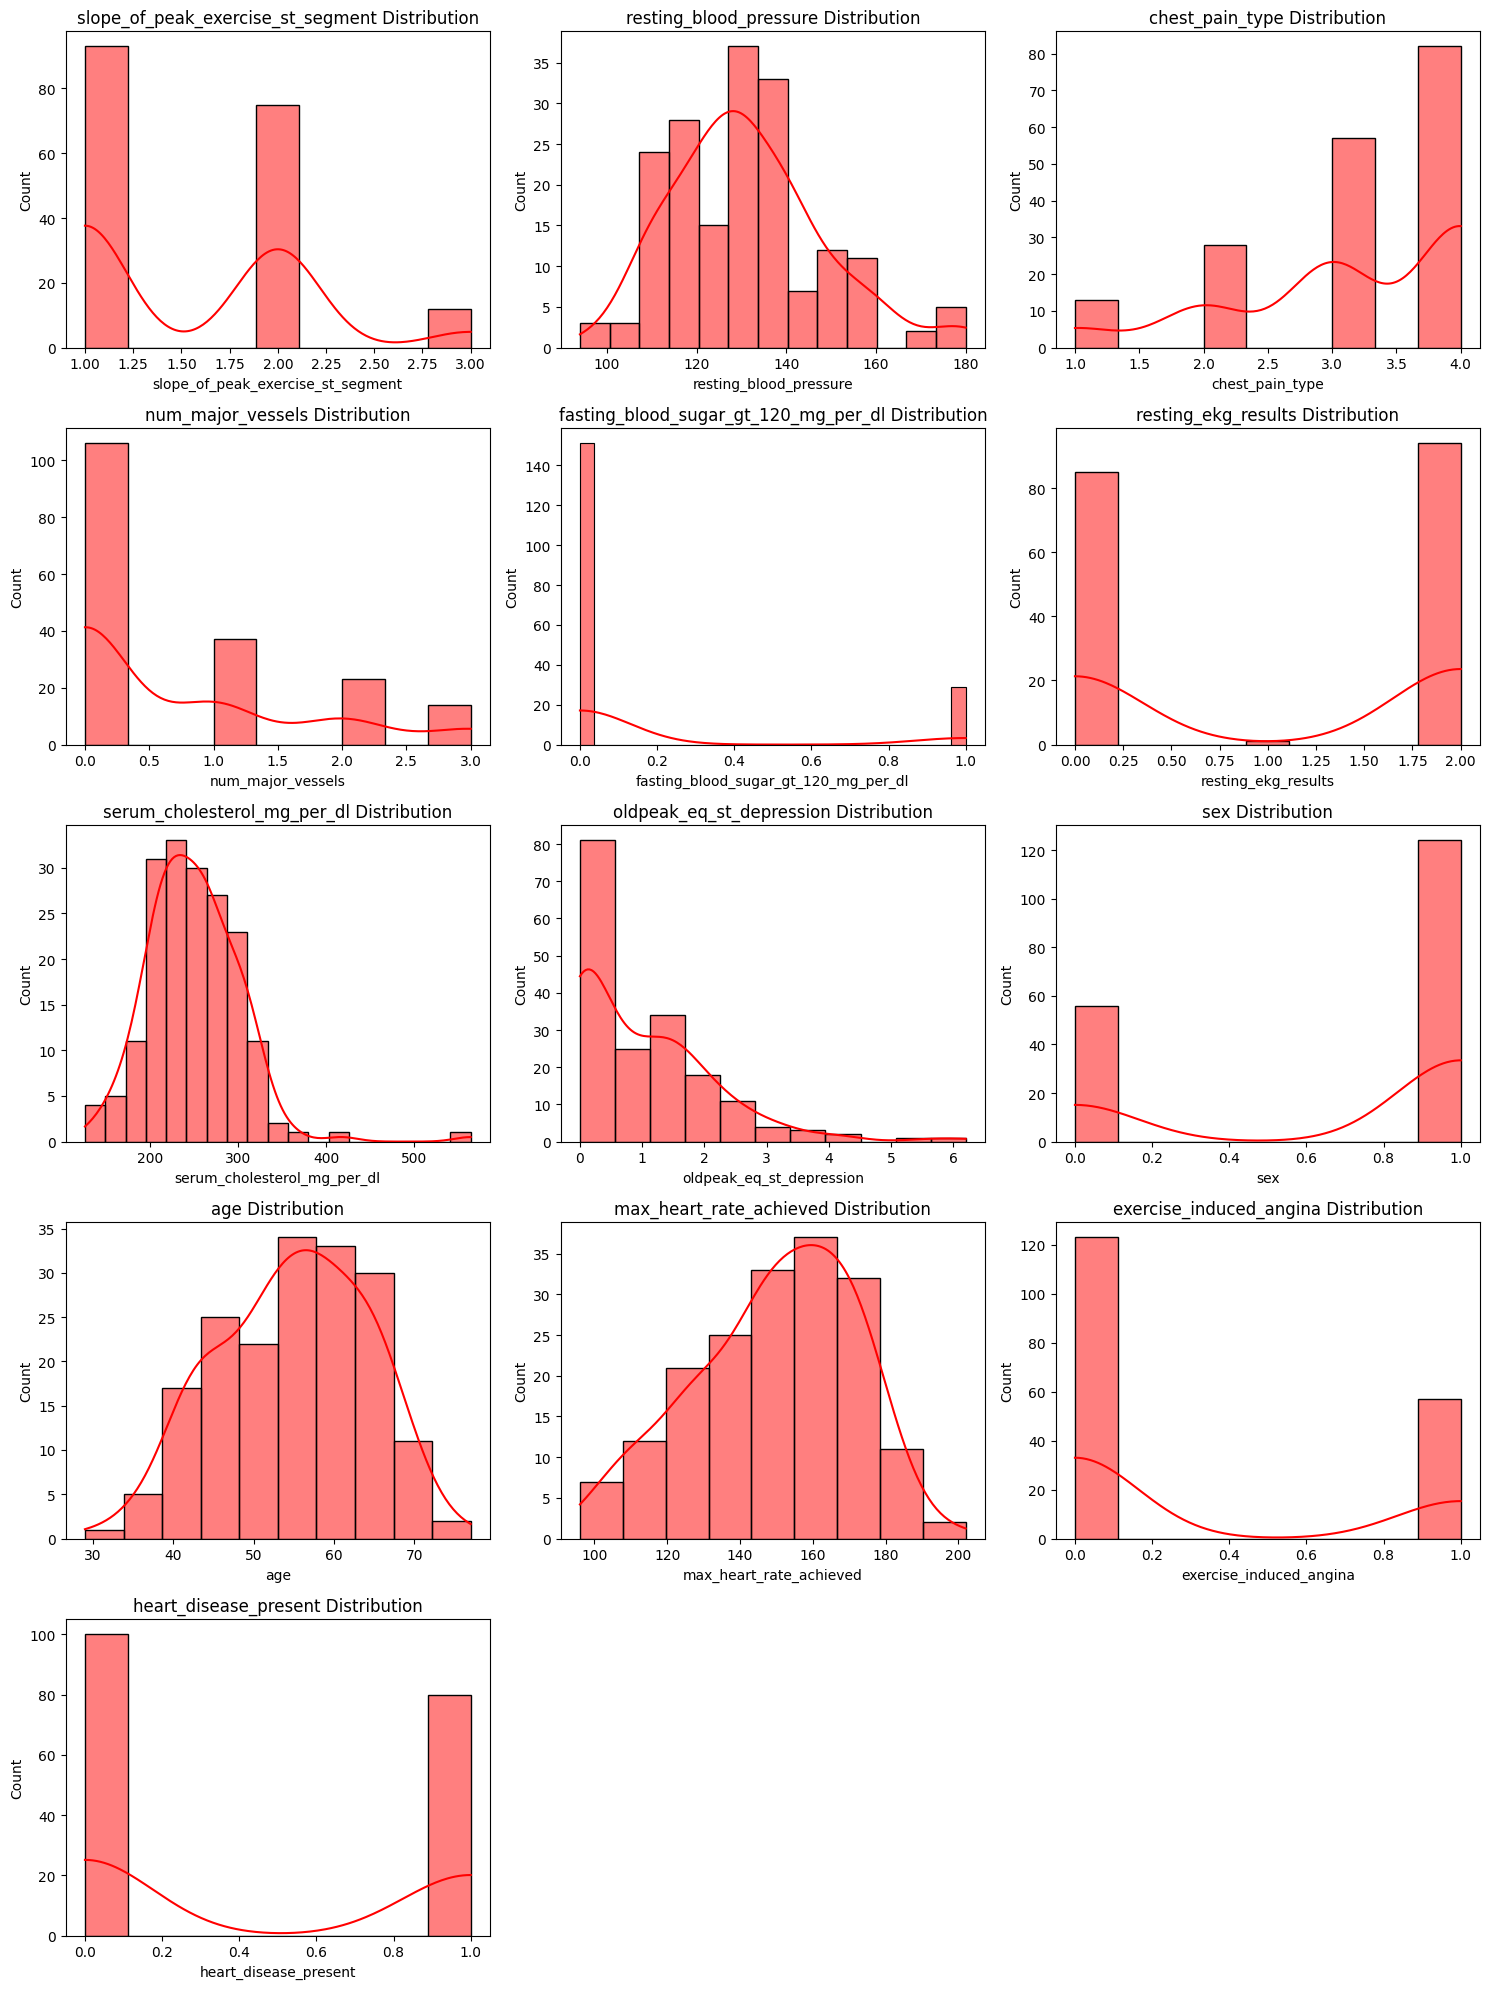

In [27]:
import math
numeric_cols = combined_data.select_dtypes(include='number').columns


# Decide grid size automatically
n = len(numeric_cols)
rows = math.ceil(n/3)   # 3 plots per row
cols = 3

plt.figure(figsize=(15, rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(combined_data[col], kde=True, color="red")
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

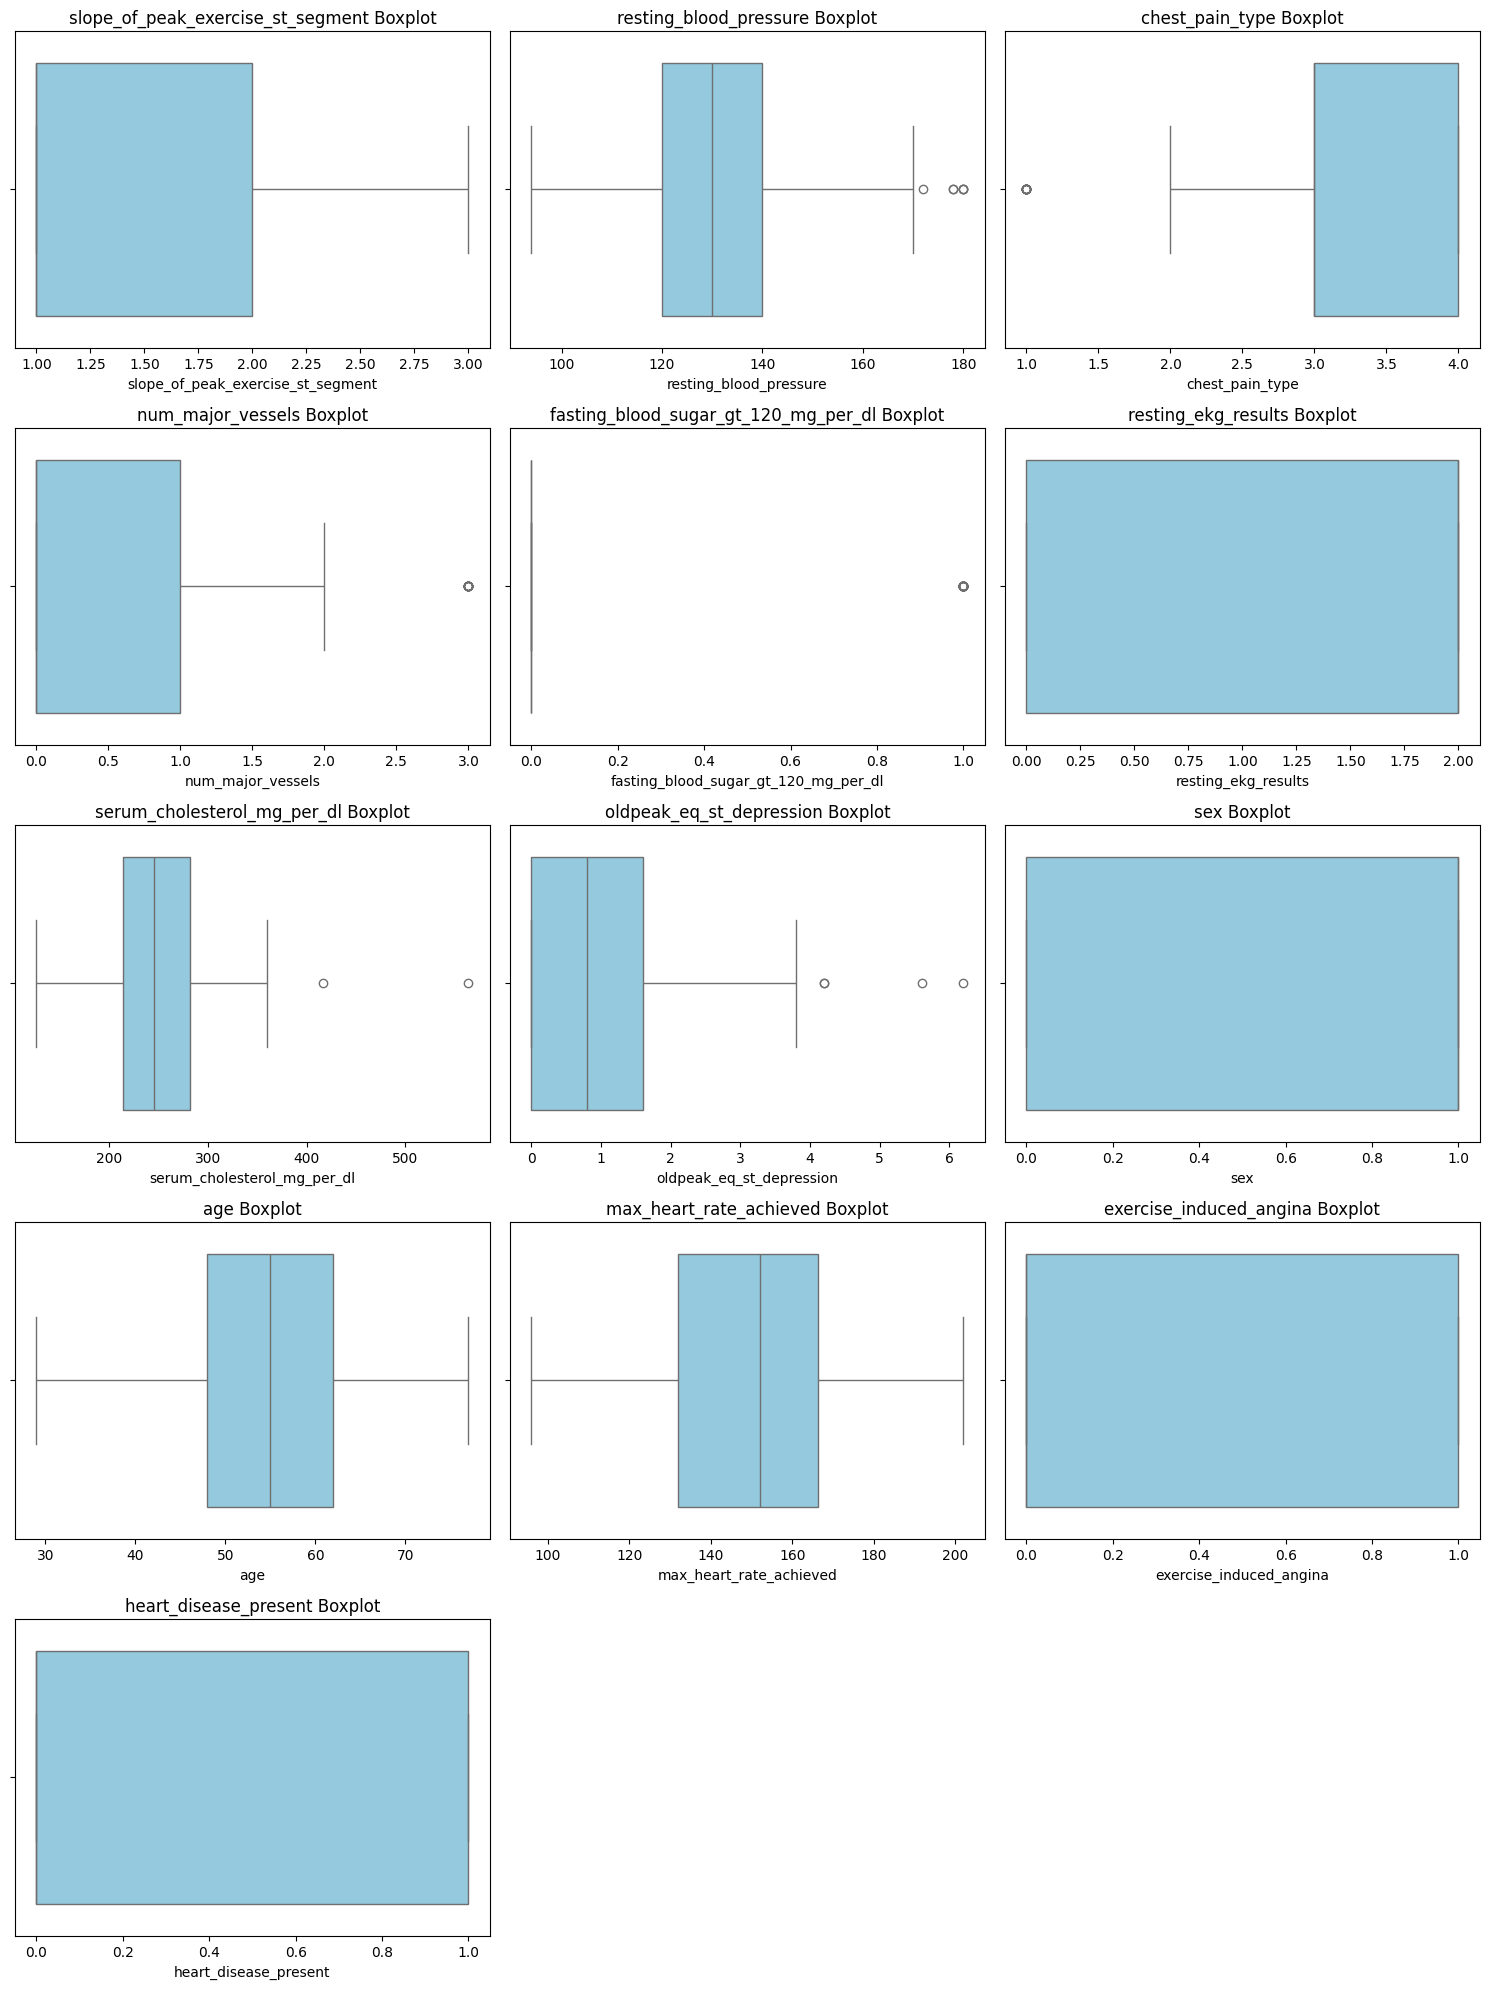

In [28]:

n = len(numeric_cols)
rows = math.ceil(n/3)   # 3 plots per row
cols = 3

plt.figure(figsize=(15, rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=combined_data[col], color="skyblue")
    plt.title(f"{col} Boxplot")

plt.tight_layout()

In [29]:
combined_data.select_dtypes(include='number').columns

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [30]:
#scatter plot check the reationship

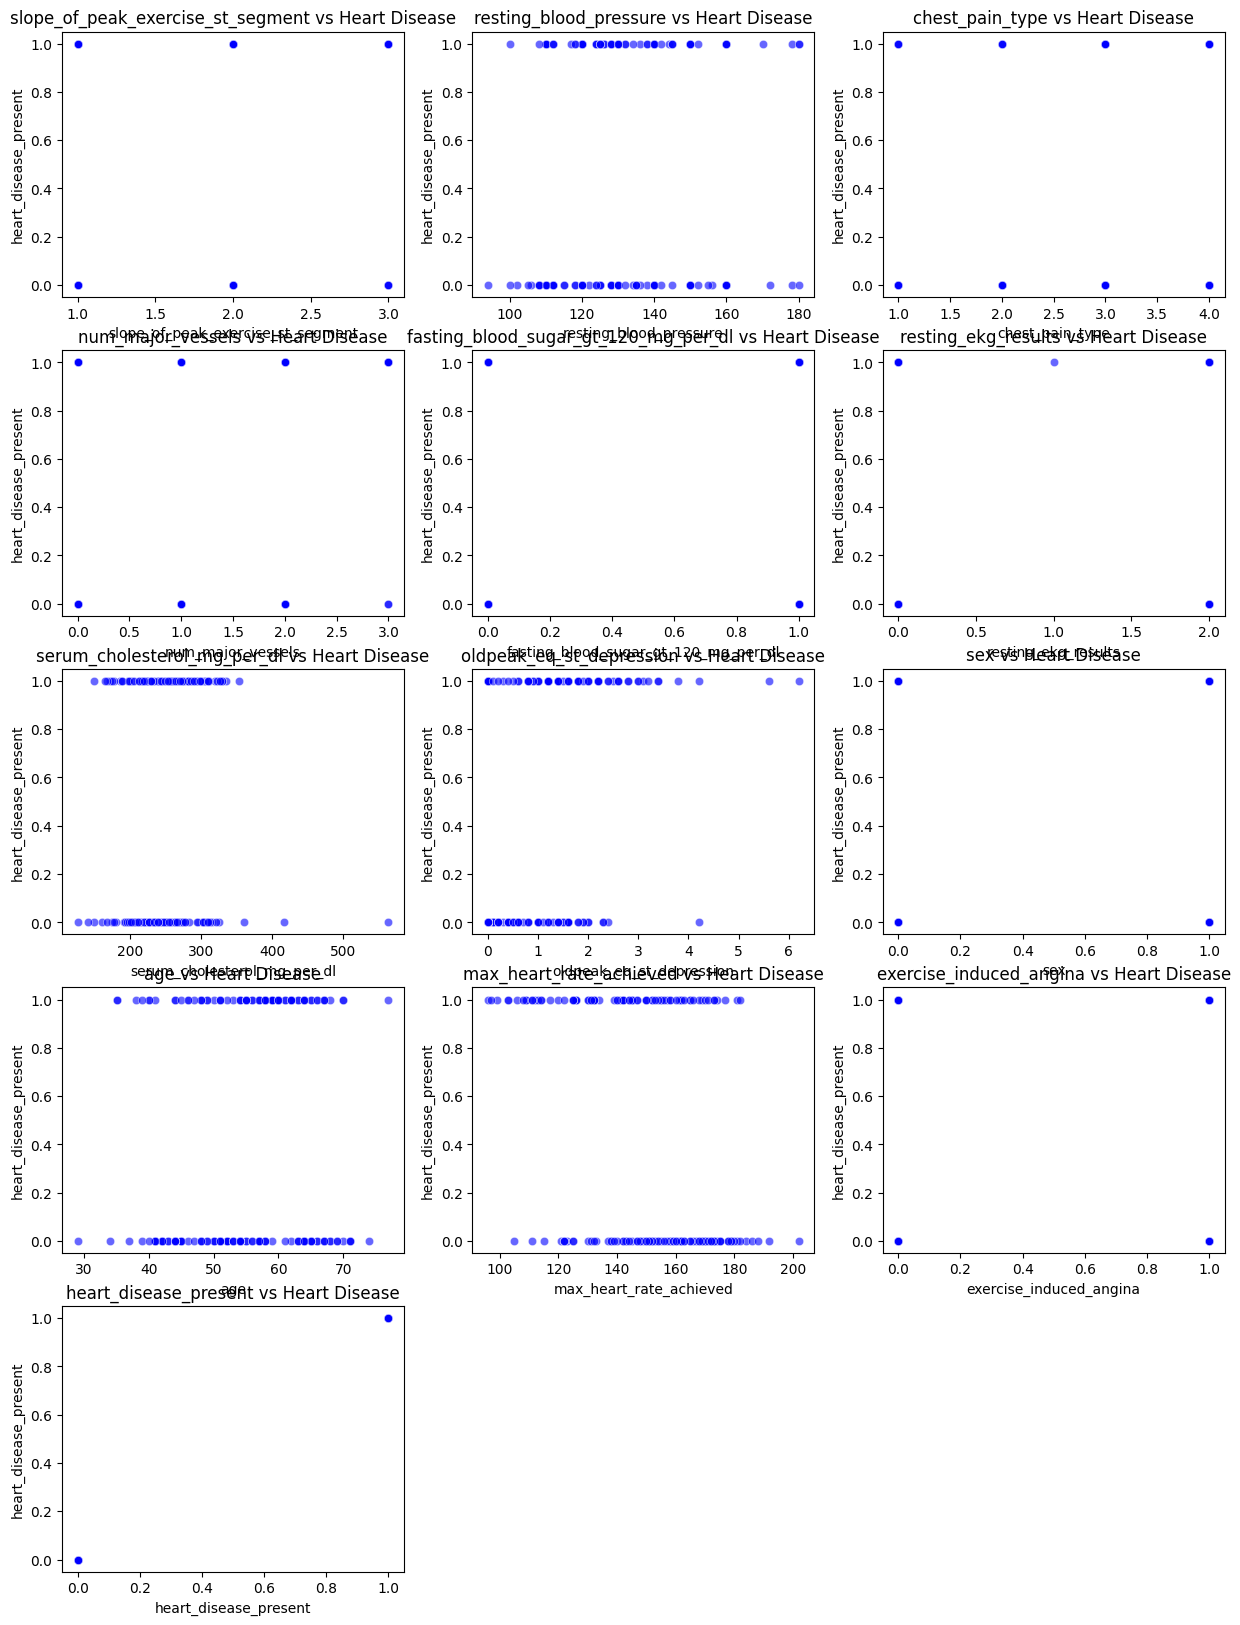

In [31]:
n = len(numeric_cols)
rows = math.ceil(n/3)   # 3 plots per row
cols = 3

plt.figure(figsize=(15, rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.scatterplot(data=combined_data, x=col, y="heart_disease_present", alpha=0.6, color="blue")
    plt.title(f"{col} vs Heart Disease")

In [32]:
num_dat=combined_data.select_dtypes(include='number')
num_dat

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0


In [33]:
res=num_dat.corr()

In [34]:
res

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
slope_of_peak_exercise_st_segment,1.000000,0.098287,0.121207,0.076832,0.050199,0.172191,-0.032348,0.615948,0.093340,0.169918,-0.418102,0.225459,0.344224
resting_blood_pressure,0.098287,1.000000,-0.029296,0.042388,0.166570,0.078986,0.144881,0.219026,-0.055589,0.284402,-0.017521,0.123397,0.078506
chest_pain_type,0.121207,-0.029296,1.000000,0.249061,-0.088992,0.033379,0.061213,0.080799,0.086057,0.085001,-0.301792,0.346266,0.412829
num_major_vessels,0.076832,0.042388,0.249061,1.000000,0.169792,0.096656,0.098348,0.214062,0.073107,0.347355,-0.275687,0.153407,0.421519
fasting_blood_sugar_gt_120_mg_per_dl,0.050199,0.166570,-0.088992,0.169792,1.000000,0.053864,0.027560,-0.039055,0.066010,0.176101,0.058369,-0.005956,0.003379
resting_ekg_results,0.172191,0.078986,0.033379,0.096656,0.053864,1.000000,0.170839,0.097321,0.045786,0.126856,-0.102766,0.037773,0.145933
serum_cholesterol_mg_per_dl,-0.032348,0.144881,0.061213,0.098348,0.027560,0.170839,1.000000,-0.021932,-0.152296,0.236211,-0.071038,0.083139,0.079775
oldpeak_eq_st_depression,0.615948,0.219026,0.080799,0.214062,-0.039055,0.097321,-0.021932,1.000000,0.099374,0.189700,-0.341045,0.249167,0.382930
sex,0.093340,-0.055589,0.086057,0.073107,0.066010,0.045786,-0.152296,0.099374,1.000000,-0.148997,-0.053960,0.251096,0.335421
age,0.169918,0.284402,0.085001,0.347355,0.176101,0.126856,0.236211,0.189700,-0.148997,1.000000,-0.394630,0.081811,0.138255


In [35]:
res[res>0.8]

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
slope_of_peak_exercise_st_segment,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_blood_pressure,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chest_pain_type,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_major_vessels,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fasting_blood_sugar_gt_120_mg_per_dl,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_ekg_results,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
serum_cholesterol_mg_per_dl,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
oldpeak_eq_st_depression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [36]:
#heatmap

In [37]:
num=combined_data.select_dtypes(exclude='object')

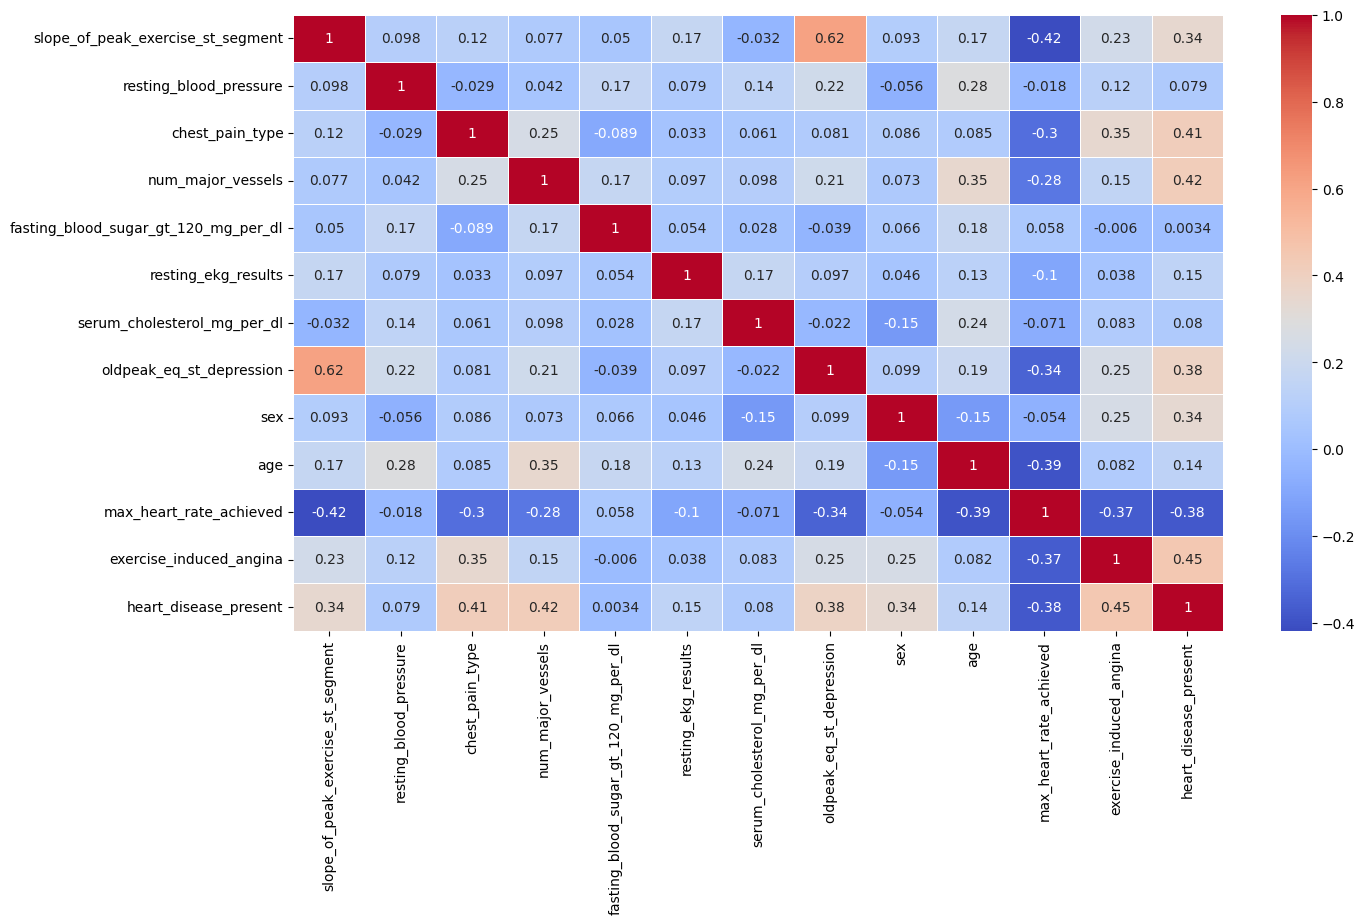

In [38]:
plt.figure(figsize=(15,8))
heatmap=sns.heatmap(num.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

## OUTLIER TREATMENT

In [39]:
def outlier_det(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [40]:
outlier_det(combined_data['slope_of_peak_exercise_st_segment'])

(np.float64(-0.5), np.float64(3.5))

In [41]:
combined_data.select_dtypes(include='number')

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0


In [42]:
for i in ['resting_blood_pressure','chest_pain_type','num_major_vessels',
          'fasting_blood_sugar_gt_120_mg_per_dl','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression']:
    lw,uw=outlier_det(combined_data[i])
    combined_data[i]=np.where(combined_data[i]<lw,lw,combined_data[i])
    combined_data[i]=np.where(combined_data[i]<uw,uw,combined_data[i])

In [43]:
combined_data[numeric_cols].describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.0,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,170.266667,5.5,2.538889,0.161111,1.050000,383.700000,4.023333,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,1.530327,0.0,0.134284,0.368659,0.998742,13.756319,0.203077,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,170.000000,5.5,2.500000,0.000000,0.000000,382.500000,4.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,170.000000,5.5,2.500000,0.000000,0.000000,382.500000,4.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,170.000000,5.5,2.500000,0.000000,2.000000,382.500000,4.000000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,170.000000,5.5,2.500000,0.000000,2.000000,382.500000,4.000000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,5.5,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


array([[<Axes: title={'center': 'slope_of_peak_exercise_st_segment'}>]],
      dtype=object)

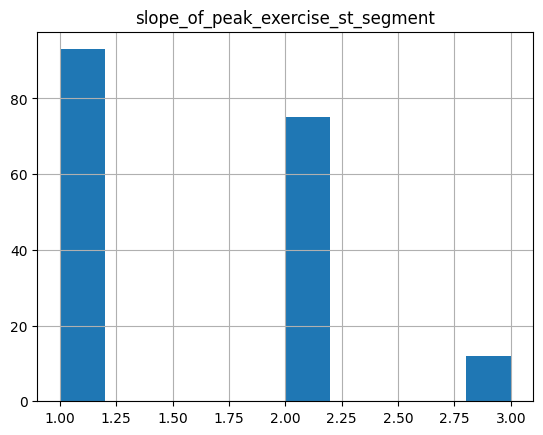

In [44]:
combined_data.hist(column='slope_of_peak_exercise_st_segment')

## FEAUTURE ENGINERRING

In [45]:
combined_data['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [46]:
combined_data['thal'].value_counts()

thal
normal               98
reversible_defect    74
fixed_defect          8
Name: count, dtype: int64

In [47]:
from sklearn.preprocessing import OrdinalEncoder
le=OrdinalEncoder()
combined_data['thal']=le.fit_transform(combined_data[['thal']])

In [48]:
combined_data

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,1.0,170.0,5.5,2.5,0.0,2,382.5,4.0,1,45,170,0,0
1,2,1.0,170.0,5.5,2.5,0.0,0,382.5,4.0,0,54,158,0,0
2,1,1.0,170.0,5.5,3.0,0.0,2,382.5,4.0,1,77,162,1,1
3,1,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,40,181,0,1
4,3,2.0,178.0,5.5,2.5,0.0,2,382.5,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,2.0,170.0,5.5,2.5,1.0,0,382.5,4.0,1,67,163,0,1
176,2,1.0,180.0,5.5,2.5,0.0,1,382.5,4.0,0,55,117,1,1
177,2,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,64,131,1,1
178,1,1.0,170.0,5.5,2.5,1.0,0,382.5,4.0,1,48,175,0,0


In [49]:
x=combined_data.iloc[:,:-1]
x

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,1,1.0,170.0,5.5,2.5,0.0,2,382.5,4.0,1,45,170,0
1,2,1.0,170.0,5.5,2.5,0.0,0,382.5,4.0,0,54,158,0
2,1,1.0,170.0,5.5,3.0,0.0,2,382.5,4.0,1,77,162,1
3,1,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,40,181,0
4,3,2.0,178.0,5.5,2.5,0.0,2,382.5,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,2.0,170.0,5.5,2.5,1.0,0,382.5,4.0,1,67,163,0
176,2,1.0,180.0,5.5,2.5,0.0,1,382.5,4.0,0,55,117,1
177,2,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,64,131,1
178,1,1.0,170.0,5.5,2.5,1.0,0,382.5,4.0,1,48,175,0


In [50]:
y=combined_data.iloc[:,-1]
y

0      0
1      0
2      1
3      1
4      0
      ..
175    1
176    1
177    1
178    0
179    0
Name: heart_disease_present, Length: 180, dtype: int64

In [51]:
x.shape

(180, 13)

In [52]:
y.shape

(180,)

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=27,stratify=y)

In [55]:
x_train

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
89,1,1.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,55,155,0
67,2,1.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,43,181,0
3,1,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,40,181,0
93,2,2.0,170.0,5.5,2.5,0.0,2,382.5,4.0,1,60,170,0
136,1,2.0,170.0,5.5,2.5,1.0,2,382.5,4.0,1,48,150,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,1,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,51,173,1
140,3,2.0,170.0,5.5,2.5,0.0,0,382.5,5.6,1,55,111,1
128,3,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,70,125,1
14,2,2.0,170.0,5.5,2.5,0.0,0,382.5,4.0,1,38,182,1


In [56]:
y_test

65     1
105    0
169    0
9      0
23     0
83     1
54     1
25     0
15     1
95     0
63     0
47     0
30     0
106    0
177    1
38     0
124    1
80     0
82     1
178    0
162    1
98     0
6      1
71     0
4      0
57     1
81     1
117    1
123    0
167    1
40     0
61     1
20     0
152    1
8      1
88     0
Name: heart_disease_present, dtype: int64

In [57]:
y_train

89     0
67     0
3      1
93     1
136    1
      ..
173    1
140    1
128    1
14     1
49     0
Name: heart_disease_present, Length: 144, dtype: int64

In [58]:
y_test

65     1
105    0
169    0
9      0
23     0
83     1
54     1
25     0
15     1
95     0
63     0
47     0
30     0
106    0
177    1
38     0
124    1
80     0
82     1
178    0
162    1
98     0
6      1
71     0
4      0
57     1
81     1
117    1
123    0
167    1
40     0
61     1
20     0
152    1
8      1
88     0
Name: heart_disease_present, dtype: int64

## MODEL CREATION AND PREDICTION
#### 1. LOGISTIC REGRESSION

In [59]:
from sklearn.linear_model import LogisticRegression
cls_model=LogisticRegression(max_iter=1000)

In [61]:
cls_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

In [62]:
y_pred=cls_model.predict(x_test)

In [63]:
y_pred

array([1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0])

##### MODEL EVALUATION METRICS

In [64]:
from sklearn.metrics import *

In [65]:
xtrain=cls_model.predict(x_train)
preds=accuracy_score(xtrain,y_train)
print('training data accuracy:',preds)

training data accuracy: 0.8194444444444444


In [66]:
xtest=cls_model.predict(x_test)
preds1=accuracy_score(xtest,y_test)
print('testing data accuracy:',preds1)

testing data accuracy: 0.6944444444444444


In [67]:
accuracy_score(y_pred,y_test)*100

69.44444444444444

In [68]:
cm = confusion_matrix(y_pred,y_test)

In [69]:
cm

array([[13,  4],
       [ 7, 12]])

<Axes: >

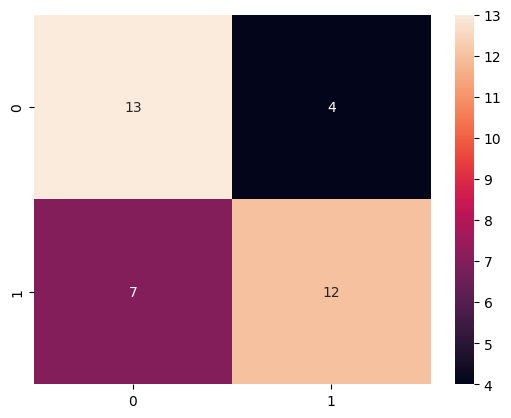

In [70]:
sns.heatmap(cm,annot=True)

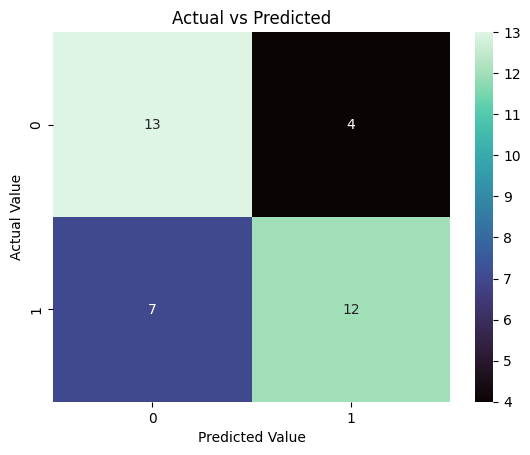

In [71]:
plt.title('Actual vs Predicted')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [72]:
precsion_score=precision_score(y_test,y_pred)
print('presion_score:',precsion_score)

presion_score: 0.631578947368421


In [73]:
rs = recall_score(y_test,y_pred)
print('Recall Score is: ',rs)

Recall Score is:  0.75


In [74]:
f1_sc = f1_score(y_test,y_pred)

In [75]:
f1_sc

0.6857142857142857

In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.65      0.70        20
           1       0.63      0.75      0.69        16

    accuracy                           0.69        36
   macro avg       0.70      0.70      0.69        36
weighted avg       0.71      0.69      0.70        36



In [77]:
user_input=(1,	1,	160,	3,	1,	0	,0,	201,	0.0,	0,	54,	163,	0	)
user_Input_array=np.asarray(user_input)
user_Input_array=np.asarray([user_input])

In [78]:
user_input

(1, 1, 160, 3, 1, 0, 0, 201, 0.0, 0, 54, 163, 0)

In [80]:
cls_model.predict([user_input])

array([1])

## DECISICION TREE CLASSIFIER

In [81]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
dt_model = DecisionTreeClassifier()
dt_model .fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

**In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

In [83]:
y_pred=dt_model.predict(x_test)

In [84]:
y_pred

array([0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0])

In [86]:
print('Accuracy Score: ',accuracy_score(y_test,y_pred))
print('Precision Score: ',precision_score(y_test,y_pred))
print('Recall Score: ',recall_score(y_test,y_pred))
print('F1 Score: ',f1_score(y_test,y_pred))

Accuracy Score:  0.6111111111111112
Precision Score:  0.55
Recall Score:  0.6875
F1 Score:  0.6111111111111112


In [87]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.55      0.61        20
           1       0.55      0.69      0.61        16

    accuracy                           0.61        36
   macro avg       0.62      0.62      0.61        36
weighted avg       0.63      0.61      0.61        36



In [88]:
from sklearn.tree import plot_tree

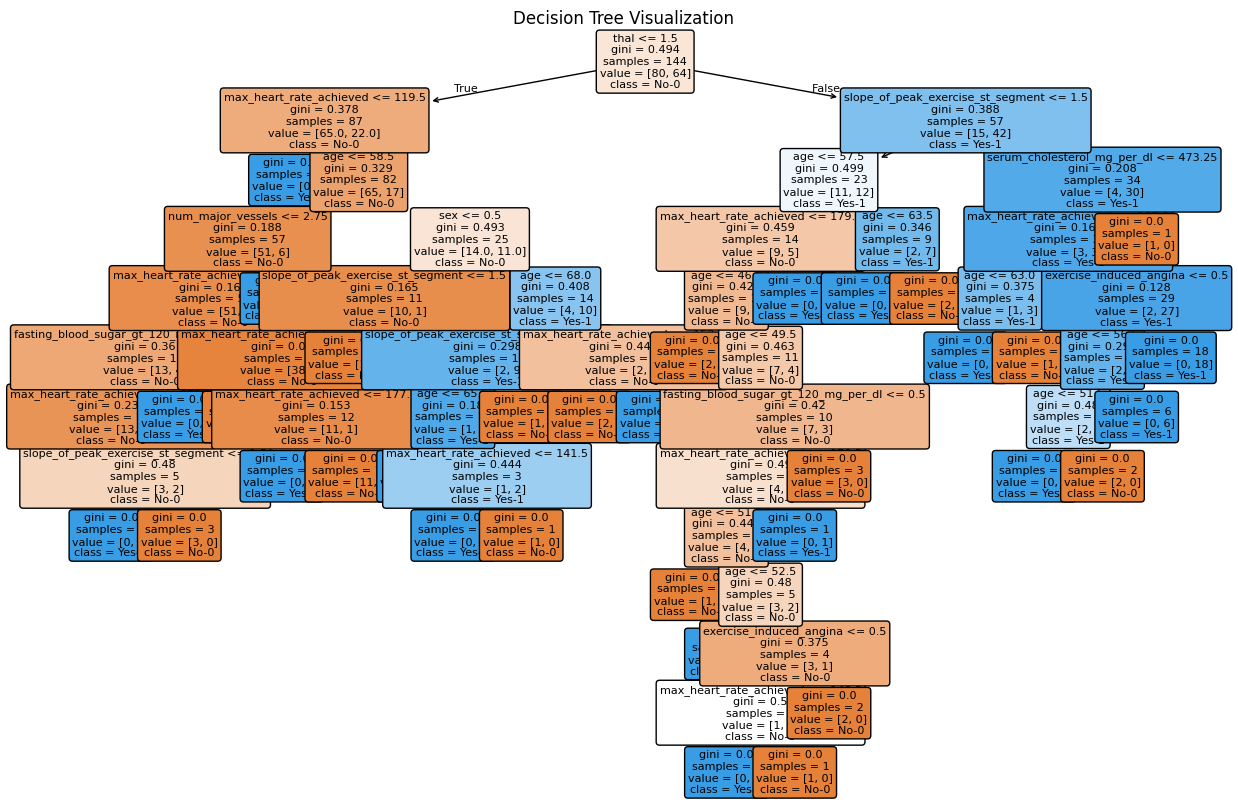

In [89]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))  # Adjust figure size for better readability

plot_tree(dt_model, 
          feature_names=x.columns,     # Column names
          class_names=['No-0', 'Yes-1'], # Class labels
          filled=True,                 # Fill nodes with colors
          rounded=True,                # Rounded corners
          fontsize=8)                  # Font size for readability

plt.title("Decision Tree Visualization")
plt.show()

## RANDOM FOREST

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
rf_model=RandomForestClassifier()
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

In [92]:
y_pred_rf=rf_model.predict(x_test)

In [93]:
y_pred_rf

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0])

## XGBOOST

In [94]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

In [95]:
y_pred_xgb

array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0])

In [96]:
accuracy_score(y_test,y_pred_xgb)

0.8888888888888888

In [97]:
#List of models you trained
models = {
    "Logistic Regression": cls_model,
    "Decision Tree": dt_model,
    "Random Forest":rf_model,
    "XGBoost": xgb_model
}

# Dictionary to store results
results = {}

for name, model in models.items():
    # Predict
    y_pred = model.predict(x_test)
    
    # Store evaluation metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

# Show results in table format
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression  0.694444   0.631579  0.7500  0.685714
Decision Tree        0.611111   0.550000  0.6875  0.611111
Random Forest        0.833333   0.812500  0.8125  0.812500
XGBoost              0.888889   0.833333  0.9375  0.882353


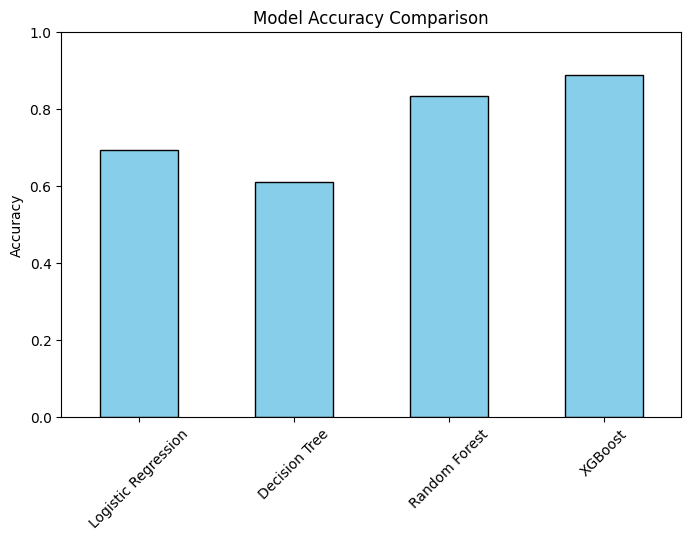

In [98]:
acc_df = results_df["Accuracy"]

# Plot bar chart
plt.figure(figsize=(8,5))
acc_df.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)   # accuracy between 0 and 1
plt.xticks(rotation=45)
plt.show()

In [99]:
user_input1=(1	,1,128,	2,	0,	0,	2	,308,	0.0	,1	,45,	170,	0	)
user_Input_array=np.asarray(user_input1)

In [100]:
xgb_model.predict([user_Input_array])

array([0])

## MODEL DEPLOYMENT

In [101]:
import pickle

In [102]:
pickle.dump(xgb_model,open('xgbmodel.pkl','wb'))

In [103]:
pickled_model=pickle.load(open('xgbmodel.pkl','rb'))

##  Conclusion

This project demonstrates the effectiveness of Machine Learning in predicting heart disease using clinical data. Proper preprocessing, handling of imbalanced data, and model tuning significantly improved predictive accuracy.

The developed model can assist healthcare professionals in early diagnosis and decision-making.

---

##  Future Scope

- Integration with hospital databases
- Real-time patient data input
- Mobile application development
- Implementation of Deep Learning models
- Expanding dataset for better generalization